# 03 — Expected Goals: an interpretable baseline

The first predictive model of the project. Everything statistical and every model
component comes from `src/football_intelligence/`; this notebook chooses the
design, runs it, and interprets the result.

## 1. Problem definition

**The question.** Given what was knowable at the moment a shot was struck, what is
the probability that it ends in a goal?

**Why this is not a classification problem.** The outcome of every shot in the
dataset is already known, so nothing useful is gained by a yes/no verdict. What is
wanted is a *probability*, and it must mean what it says: of all the shots assigned
0.15, about 15% should be goals. That requirement drives everything below —
the choice of model, the choice of metrics, and the refusal to report accuracy.

**Observational unit.** One shot. **Target:** `goal`, a boolean.

**Why logistic regression first.** It produces probabilities directly, its
coefficients can be read as changes in log odds, and it fits in a second. A
gradient-boosted model may well beat it later, but "beat it" is only a meaningful
claim against a baseline that was given a fair chance.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, roc_curve

from football_intelligence.evaluation import metrics as mx
from football_intelligence.evaluation import validation as val
from football_intelligence.features import shots as shot_features
from football_intelligence.models import logistic as lg


def find_repository_root(start: Path) -> Path:
    """Walk upwards until the directory containing pyproject.toml is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError(f"No pyproject.toml above {start}")


REPO_ROOT = find_repository_root(Path.cwd())
SEED = 20260823

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 150)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"

shots = shot_features.read_shot_dataset(REPO_ROOT / shot_features.DEFAULT_DATASET_PATH)
print(
    f"shots: {len(shots):,}   matches: {shots['match_id'].nunique()}   "
    f"players: {shots['player_id'].nunique()}"
)
print(f"features declared by the dataset: {len(shot_features.FEATURE_COLUMNS)}")

shots: 2,918   matches: 115   players: 651
features declared by the dataset: 19


---

## 2. The target and its prevalence

Before modelling: how rare is the event, and what does a model that learns nothing
achieve?

In [2]:
prevalence = shots["goal"].mean()
print(f"shots           {len(shots):,}")
print(f"goals           {int(shots['goal'].sum()):,}")
print(f"prevalence      {prevalence:.4f}")
print()
print("A model predicting the base rate for every shot would score:")
naive = mx.evaluate_probabilities(shots["goal"], np.full(len(shots), prevalence))
print(naive)

shots           2,918
goals           288
prevalence      0.0987

A model predicting the base rate for every shot would score:
  n / positives     2,918 / 288 (prevalence 0.0987)
  ROC-AUC           0.5000   (0.5 = no discrimination)
  PR-AUC            0.0987   (baseline = prevalence = 0.0987)
  log loss          0.3222   (base rate 0.3222, skill +0.0000)
  Brier score       0.0890   (base rate 0.0890, skill +0.0000)
  mean prediction   0.0987   (observed 0.0987, bias +0.0000)


**Prevalence is 9.87%**, so roughly one shot in ten is a goal.

Two consequences follow immediately:

1. **Accuracy is useless here.** A model that predicts "no goal" for every shot is
   90.1% accurate and worthless. It appears nowhere in this notebook.
2. **Log loss and Brier need a reference.** The base-rate model scores a log loss
   of 0.3222 and a Brier score of 0.0890. Those are the numbers to beat, and every
   result below is reported with the corresponding *skill score*
   (`1 - metric / baseline`), which is 0 for the naive model and 1 for perfection.

Note also that the base-rate model has a ROC-AUC of exactly 0.5: it cannot order
shots at all, which is precisely what discrimination measures.

---

## 3. Leakage: what must not go into the model

Three distinct hazards, all present in this dataset.

**`statsbomb_xg` — another model's answer.** The dataset ships StatsBomb's own
expected-goals estimate for every shot. It is a model output for exactly the
quantity we are predicting, computed from information we do not otherwise use,
including the freeze frame of defender positions. Training on it would produce
excellent metrics measuring how well we copy StatsBomb, not how well we model
goals. It is used here **only** as a benchmark, and `build_pipeline` refuses to
accept it as a feature so the mistake cannot happen by accident.

**Post-shot information.** `end_x`, `end_y`, `end_z` describe where the ball
crossed the goal line — knowable only after the shot. A model given them would
"discover" that shots ending inside the goal frame tend to be goals. These are on
the same rejection list.

**Structural leakage through the split.** Shots are clustered within matches. A
random split of shot rows puts shots from the same match on both sides, so the test
set is not independent of training. That is §4.

In [3]:
print("Features the model layer refuses, with the reason:\n")
for name, reason in lg.FORBIDDEN_FEATURES.items():
    print(f"  {name:<14} {reason}")

print("\nAttempting to build a model on the StatsBomb estimate:")
try:
    lg.build_pipeline(("shot_distance", "statsbomb_xg"))
except lg.ModelError as error:
    print(f"  refused -> {error}")

Features the model layer refuses, with the reason:

  statsbomb_xg   another model's estimate of the target, computed from information this model does not use; keep it as a benchmark
  goal           the target itself
  outcome        the target in categorical form
  outcome_id     the target in categorical form
  end_x          recorded after the shot was struck
  end_y          recorded after the shot was struck
  end_z          recorded after the shot was struck

Attempting to build a model on the StatsBomb estimate:
  refused -> 'statsbomb_xg' cannot be used as a feature: another model's estimate of the target, computed from information this model does not use; keep it as a benchmark.


---

## 4. Train/test design: split matches, not shots

**The design.** 25% of *matches* are held out. Every shot from a held-out match
goes to the test set and none of them are seen in training, so the evaluation
answers "how does this model do on a match it has never seen?" — the question that
matters in use.

**The alternative and why it is wrong.** A random 75/25 split of shot rows is the
tutorial default. With 115 matches and ~25 shots each, essentially every match would
appear on both sides. The model would be tested on matches it had partly memorised,
and the reported performance would be optimistic by an unknown amount.

`match_id` is preserved in both frames so the absence of overlap can be checked
rather than assumed, and `assert_no_group_leakage` does exactly that.

In [4]:
split = val.group_train_test_split(
    shots, group_column="match_id", test_size=0.25, random_state=SEED
)
val.assert_no_group_leakage(split)
print(split)
print()
print(
    f"train prevalence {split.train['goal'].mean():.4f}   "
    f"test prevalence {split.test['goal'].mean():.4f}"
)

# What a naive row-level split would have done, for comparison only.
shuffled = shots.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
cut = int(0.75 * len(shuffled))
naive_train, naive_test = shuffled.iloc[:cut], shuffled.iloc[cut:]
shared = set(naive_train["match_id"]) & set(naive_test["match_id"])
print(
    f"\nmatches spanning both sides of a random row split: {len(shared)} of "
    f"{shots['match_id'].nunique()}"
)
print(f"matches spanning both sides of the group split:     {len(split.overlapping_groups)}")

  train  2,172 rows from 86 match_id groups
  test   746 rows from 29 match_id groups
  groups on both sides: 0

train prevalence 0.0981   test prevalence 0.1005

matches spanning both sides of a random row split: 115 of 115
matches spanning both sides of the group split:     0


**Result.** The group split gives 86 training matches and 29 test matches, with
**zero** overlap. A random row split would have put **all 115 matches on both
sides** — the model would have seen part of almost every match it was then tested
on.

Test prevalence (10.05%) is close to training prevalence (9.81%), which is
reassuring but not guaranteed by the design: splitting on matches means the goal
rate in the test set is itself random.

---

## 5. The geometry baseline: distance and angle

**Features.** `shot_distance` (yards to the goal centre) and `shot_angle` (radians
subtended by the two posts). Both were derived and unit-tested in the feature
layer, and both are known before the ball is struck.

**Why start here.** These two numbers encode most of what makes a chance good: how
far you are, and how much goal you can see. Anything more elaborate should have to
prove it adds something.

In [5]:
baseline = lg.fit(lg.build_baseline_model(random_state=SEED), split.train)
baseline_test = lg.predict_probability(baseline, split.test)

print("features used:", lg.feature_columns(baseline))
print()
print(mx.evaluate_probabilities(split.test["goal"], baseline_test))

features used: ['shot_distance', 'shot_angle']

  n / positives     746 / 75 (prevalence 0.1005)
  ROC-AUC           0.7420   (0.5 = no discrimination)
  PR-AUC            0.2753   (baseline = prevalence = 0.1005)
  log loss          0.2903   (base rate 0.3263, skill +0.1102)
  Brier score       0.0828   (base rate 0.0904, skill +0.0841)
  mean prediction   0.0965   (observed 0.1005, bias -0.0040)


---

## 6. Adding pre-shot context

**Features added.** `body_part`, `shot_type`, `technique` (categorical, with levels
rarer than 1% pooled into an "infrequent" bucket), plus `under_pressure` and
`first_time` (booleans).

**Why these and not more.** Each is knowable before the shot and each describes a
distinct mechanism: heading is not shooting, a penalty is not open play, a volley
gives less control, a closing defender changes the chance. Features such as
`one_on_one` or `open_goal` were left out on purpose — they are very rare (113 and
32 shots) and shade into describing the outcome rather than the chance.

Rare categorical levels are pooled rather than given their own coefficient: with
twelve backheels in the dataset, a backheel coefficient would be noise with a
standard error attached.

In [6]:
contextual = lg.fit(lg.build_contextual_model(random_state=SEED), split.train)
contextual_test = lg.predict_probability(contextual, split.test)

print("features used:", lg.feature_columns(contextual))
print()
print(mx.evaluate_probabilities(split.test["goal"], contextual_test))

features used: ['shot_distance', 'shot_angle', 'body_part', 'shot_type', 'technique', 'under_pressure', 'first_time']

  n / positives     746 / 75 (prevalence 0.1005)
  ROC-AUC           0.7568   (0.5 = no discrimination)
  PR-AUC            0.2995   (baseline = prevalence = 0.1005)
  log loss          0.2845   (base rate 0.3263, skill +0.1281)
  Brier score       0.0813   (base rate 0.0904, skill +0.1011)
  mean prediction   0.0980   (observed 0.1005, bias -0.0025)


---

## 7. Metrics, side by side

All three sets of predictions are scored on the **same** held-out matches. The
StatsBomb column is included as a reference point only — it was never trained on,
and its presence here is a benchmark, not a model of ours.

In [7]:
comparison = mx.compare_models(
    split.test["goal"],
    {
        "base rate": np.full(len(split.test), split.train["goal"].mean()),
        "distance + angle": baseline_test,
        "+ context": contextual_test,
        "StatsBomb xG (reference)": split.test["statsbomb_xg"].to_numpy(),
    },
)
display(
    comparison[
        [
            "roc_auc",
            "pr_auc",
            "log_loss",
            "log_loss_skill",
            "brier_score",
            "brier_skill",
            "mean_prediction",
        ]
    ].round(4)
)

,roc_auc,pr_auc,log_loss,log_loss_skill,brier_score,brier_skill,mean_prediction
base rate,0.5000,0.1005,0.3263,-0.0001,0.0904,-0.0001,0.0981
distance + angle,0.7420,0.2753,0.2903,0.1102,0.0828,0.0841,0.0965
+ context,0.7568,0.2995,0.2845,0.1281,0.0813,0.1011,0.0980
StatsBomb xG (reference),0.7840,0.4002,0.2692,0.1749,0.0756,0.1636,0.1042


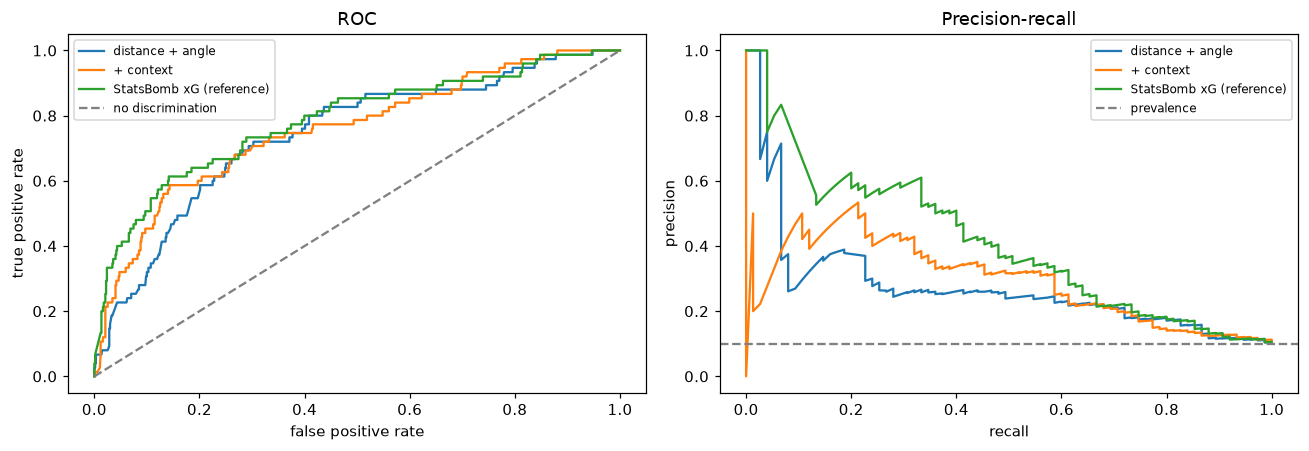

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
curves = {
    "distance + angle": baseline_test,
    "+ context": contextual_test,
    "StatsBomb xG (reference)": split.test["statsbomb_xg"].to_numpy(),
}
truth = split.test["goal"].to_numpy()

for name, probabilities in curves.items():
    false_positive, true_positive, _ = roc_curve(truth, probabilities)
    axes[0].plot(false_positive, true_positive, label=name)
axes[0].plot([0, 1], [0, 1], color="grey", linestyle="--", label="no discrimination")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC")
axes[0].legend(fontsize=8)

for name, probabilities in curves.items():
    precision, recall, _ = precision_recall_curve(truth, probabilities)
    axes[1].plot(recall, precision, label=name)
axes[1].axhline(truth.mean(), color="grey", linestyle="--", label="prevalence")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].set_title("Precision-recall")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

**Result on 746 held-out shots from 29 unseen matches.**

| model | ROC-AUC | PR-AUC | log loss | Brier skill |
| --- | ---: | ---: | ---: | ---: |
| base rate | 0.500 | 0.101 | 0.3263 | 0.000 |
| distance + angle | 0.742 | 0.275 | 0.2903 | 0.084 |
| + context | 0.757 | 0.300 | 0.2845 | 0.101 |
| StatsBomb xG (reference) | 0.784 | 0.400 | 0.2692 | 0.164 |

**Reading it.**

- Both models beat the base rate on every measure, so the geometry really does
  carry information — but the **Brier skill scores of 0.08 and 0.10** say plainly
  how much: the improvement over "assume 10% for everything" is real and modest.
  A ROC-AUC of 0.74 sounds much more impressive than a Brier skill of 0.08, and the
  skill score is the more honest summary.
- **Context adds a little**: ROC-AUC 0.742 → 0.757, Brier skill 0.084 → 0.101.
  Worth having, not transformative.
- **The reference model is meaningfully better** (PR-AUC 0.400 against 0.300),
  which is expected: it uses the freeze frame — where the goalkeeper and defenders
  were standing — which our features do not contain. The gap is a measure of what
  spatial context is worth, not evidence that our model is broken.
- **Calibration in the large is good** for both of our models: mean predictions of
  0.0965 and 0.0980 against an observed 0.1005. Whether they are calibrated
  *across the range* is a separate question, and the subject of the next task.

**A caution about the single split.** These are 29 matches. Repeating the exercise
with a different seed moves every number, and a proper comparison needs grouped
cross-validation rather than one hold-out. That is the next task, and the numbers
above should be read as one draw rather than a verdict.

---

## 8. What the model learned

Coefficients are on the log-odds scale. Numeric features were standardised, so
their coefficient is the change in log odds per **one standard deviation**; each
categorical coefficient is a contrast against the dropped reference level.
Exponentiating gives an odds ratio.

In [9]:
print("BASELINE")
display(lg.coefficients(baseline).round(4))
print("CONTEXTUAL")
display(lg.coefficients(contextual).round(4))

BASELINE


,feature,coefficient,odds_ratio
0,(intercept),-2.5149,0.0809
1,shot_distance,-0.5481,0.5780
2,shot_angle,0.3754,1.4556


CONTEXTUAL


,feature,coefficient,odds_ratio
0,(intercept),-3.1846,0.0414
1,shot_type_Penalty,1.5014,4.4880
2,body_part_Right Foot,1.0670,2.9065
3,body_part_Left Foot,0.9731,2.6462
4,shot_distance,-0.7829,0.4571
5,shot_type_Open Play,-0.7758,0.4603
6,technique_Normal,0.6247,1.8677
7,under_pressure,-0.5403,0.5826
8,shot_angle,0.4435,1.5582
9,technique_infrequent_sklearn,0.2655,1.3041


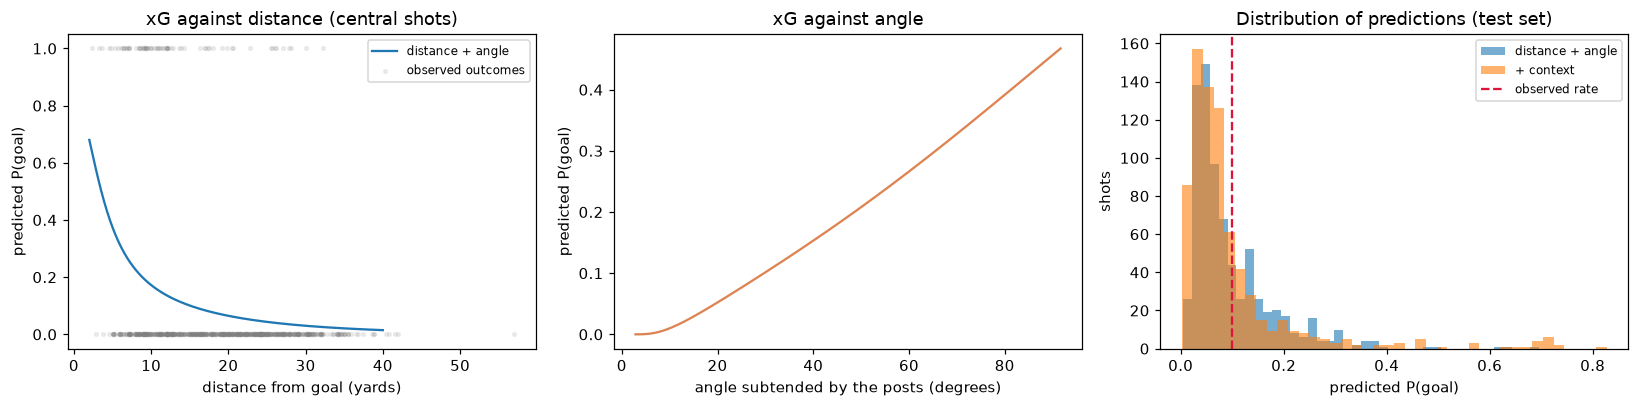

In [10]:
grid = pd.DataFrame({"shot_distance": np.linspace(2, 40, 200)})
grid["shot_angle"] = np.arctan2(
    8.0 * (120.0 - (120.0 - grid["shot_distance"])),
    grid["shot_distance"] ** 2 - 16.0,
)
central = grid.assign(shot_angle=lambda d: 2 * np.arctan(4.0 / d["shot_distance"]))

angle_grid = pd.DataFrame({"shot_angle": np.linspace(0.05, 1.6, 200)})
angle_grid["shot_distance"] = 4.0 / np.tan(angle_grid["shot_angle"] / 2.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

axes[0].plot(
    central["shot_distance"], lg.predict_probability(baseline, central), label="distance + angle"
)
axes[0].scatter(
    split.test["shot_distance"],
    split.test["goal"].astype(float),
    s=6,
    alpha=0.12,
    color="grey",
    label="observed outcomes",
)
axes[0].set_xlabel("distance from goal (yards)")
axes[0].set_ylabel("predicted P(goal)")
axes[0].set_title("xG against distance (central shots)")
axes[0].legend(fontsize=8)

axes[1].plot(
    np.degrees(angle_grid["shot_angle"]),
    lg.predict_probability(baseline, angle_grid),
    color="#DD8452",
)
axes[1].set_xlabel("angle subtended by the posts (degrees)")
axes[1].set_ylabel("predicted P(goal)")
axes[1].set_title("xG against angle")

axes[2].hist(baseline_test, bins=40, alpha=0.6, label="distance + angle")
axes[2].hist(contextual_test, bins=40, alpha=0.6, label="+ context")
axes[2].axvline(split.test["goal"].mean(), color="crimson", linestyle="--", label="observed rate")
axes[2].set_xlabel("predicted P(goal)")
axes[2].set_ylabel("shots")
axes[2].set_title("Distribution of predictions (test set)")
axes[2].legend(fontsize=8)
fig.tight_layout()
plt.show()

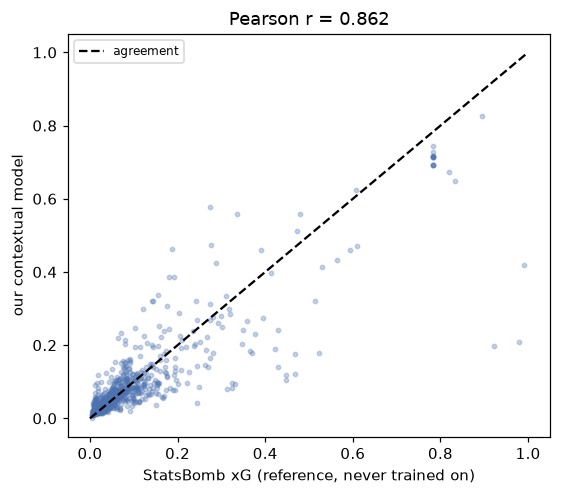

correlation with the reference model: 0.8617
our total predicted goals: 73.1
reference total:           77.8
actual goals:              75


In [11]:
reference = split.test["statsbomb_xg"]
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.scatter(reference, contextual_test, s=8, alpha=0.3, color="#4C72B0")
ax.plot([0, 1], [0, 1], color="black", linestyle="--", label="agreement")
ax.set_xlabel("StatsBomb xG (reference, never trained on)")
ax.set_ylabel("our contextual model")
ax.set_title(f"Pearson r = {np.corrcoef(reference, contextual_test)[0, 1]:.3f}")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"correlation with the reference model: {np.corrcoef(reference, contextual_test)[0, 1]:.4f}")
print(f"our total predicted goals: {contextual_test.sum():.1f}")
print(f"reference total:           {reference.sum():.1f}")
print(f"actual goals:              {int(split.test['goal'].sum())}")

**Interpretation of the coefficients.**

In the baseline, distance and angle both point the way football says they should:
the distance coefficient is **negative** (further out, worse) and the angle
coefficient **positive** (more visible goal, better). They are strongly correlated
with one another — a shot far out necessarily has a narrow angle — so neither
coefficient should be read as an isolated causal effect. That is the usual price of
collinearity, and it is why the fitted curve matters more than either number alone.

In the contextual model the largest coefficient is **`shot_type_Penalty`**, worth
about 4.5 times the odds relative to the reference level. That is the model
recovering something we already knew from the exploration: penalties convert at
67% against a 10% base rate. `under_pressure` carries a negative coefficient, as
expected.

**The curves.** Predicted xG falls steeply with distance — from around 0.4 at six
yards to under 0.03 beyond 25 — and rises with the visible goal angle. The shape is
smooth and monotone because that is what logistic regression in these features can
express; a real xG surface is neither, which is precisely the opening a
gradient-boosted or additive model will exploit later.

**The prediction distribution** is heavily concentrated below 0.2, which it should
be: most shots are not good chances. The long thin right tail is close-range
chances and penalties.

**Against the reference.** Our predictions correlate with StatsBomb's at **r =
0.862**, and the totals are close: we predict **73.1** goals against 75 actual and
StatsBomb's 77.8. Agreeing with a better model is encouraging; the residual
disagreement is largely the freeze-frame information we do not have.

**One coefficient worth not over-reading.** `shot_type_Open Play` comes out
*negative* (odds ratio 0.46) against the dropped reference level, which is
`Free Kick` — apparently saying open-play shots are worse than direct free kicks.
Marginally the opposite is true (9.1% against 5.7%). The model is reporting a
comparison *at equal distance and angle*, where a free kick is struck with a set
ball and no closing defender, and it rests on only 123 free kicks. This is exactly
why individual coefficients in a collinear model with sparse levels should be read
as part of a fitted surface rather than as standalone effects.

---

## 9. Gradient boosting: XGBoost

### What it does

Fit a very shallow tree. It will be wrong almost everywhere. Compute the gradient
of the loss with respect to the current prediction — for a log-loss classifier
this is essentially "observed minus predicted" — and fit the **next** tree to that
residual signal. Add it to the running total, scaled down by the learning rate,
and repeat. The final prediction is an additive sum of hundreds of small
corrections, each attending to what its predecessors got wrong.

Two things follow. Boosting can express **interactions and non-monotone
responses** that the logistic model cannot: a header from six yards is not
"header" plus "six yards", and a tree can say so by splitting on both. And because
every tree is fitted to the previous errors, boosting will happily go on fitting
noise — which is what everything below is designed to prevent.

### Boosting versus bagging

| | Bagging (random forest) | Boosting (XGBoost) |
| --- | --- | --- |
| How trees are built | independently, on bootstrap samples | sequentially, each correcting the last |
| Individual tree | deep, low bias, high variance | shallow, high bias, low variance |
| Averaging/summing reduces | variance | bias |
| Parallelism | trees are independent | trees are not |
| More trees | never really hurts | eventually overfits |

That last row is the whole reason boosting needs a learning rate and early
stopping while a forest needs neither.

### The knobs, and the settings used here

- **learning_rate = 0.05** — how much of each tree's correction is kept. Lower
  means slower, steadier learning that generalises better but needs more trees. It
  trades against the number of trees almost exactly.
- **n_estimators, capped at 600** — not chosen by hand. **Early stopping** picks it
  by watching a held-out slice of the *training* data and stopping when the
  validation loss stops improving for 40 rounds.
- **max_depth = 3** — how deep each tree may go, and therefore the order of
  interaction it can express. Depth 3 already allows three-way interactions. With
  fewer than 300 goals in training, deeper trees would memorise individual shots.
- **min_child_weight = 5**, **subsample = 0.8**, **colsample_bytree = 0.8** — a leaf
  must carry real evidence, and each tree sees only part of the rows and part of
  the features. Both damp the tendency to fit noise.
- **reg_lambda = 1.0** — L2 shrinkage on leaf values, pulling predictions toward
  the ensemble's current average.

**On overfitting.** A boosted model has three independent defences: shrinkage (the
learning rate), randomness (subsampling), and stopping early. Regularisation
alone would not be enough, because nothing in the algorithm stops it from adding
another tree that fits one more training point.

**These are not tuned.** They are modest, defensible defaults. A large
hyperparameter search on 2,918 shots and one hold-out split would mostly be
fitting the split.

### The comparison is deliberately like-for-like

Target, features, preprocessing, split and metrics are the same objects the
logistic model used — they live in `models.preprocessing` precisely so no model
can win by being handed different information. A test asserts the two models see
identical feature columns.

**Early stopping needs its own split, and it must also respect matches.** The
validation slice is carved out of the training data **by match**. A random row
split there would leak: shots from a validation match would also be in the
training slice, the loss curve would look optimistic, and stopping would come too
late. The test set is never involved — choosing the number of trees on the data
used to report performance would invalidate the report.

In [12]:
import time

from football_intelligence.models import xgboost as xgbm

start = time.perf_counter()
boosted = xgbm.fit_with_early_stopping(
    xgbm.build_contextual_model(random_state=SEED), split.train, random_state=SEED
)
boosted_train_seconds = time.perf_counter() - start

print(boosted)
print()
print(f"  training time     {boosted_train_seconds:.3f}s")
print(f"  trees kept        {boosted.n_trees} of a budget of {xgbm.MAX_TREES}")

  library           xgboost
  early stopping    stopped at 89 trees
  best iteration    48
  validation loss   0.2950
  validation set    439 rows from 18 held-out training matches

  training time     0.488s
  trees kept        89 of a budget of 600


In [13]:
# Time the logistic fits the same way, for a like-for-like comparison.
timings = {}
for name, builder in (
    ("logistic distance + angle", lg.build_baseline_model),
    ("logistic + context", lg.build_contextual_model),
):
    start = time.perf_counter()
    lg.fit(builder(random_state=SEED), split.train)
    timings[name] = time.perf_counter() - start
timings["xgboost + context"] = boosted_train_seconds

boosted_test = lg.predict_probability(boosted.pipeline, split.test)

inference = {}
for name, pipeline in (
    ("logistic distance + angle", baseline),
    ("logistic + context", contextual),
    ("xgboost + context", boosted.pipeline),
):
    start = time.perf_counter()
    for _ in range(20):
        lg.predict_probability(pipeline, split.test)
    inference[name] = (time.perf_counter() - start) / 20

cost = pd.DataFrame(
    {
        "train_seconds": pd.Series(timings),
        "predict_seconds_per_746_shots": pd.Series(inference),
    }
)
cost["microseconds_per_shot"] = cost["predict_seconds_per_746_shots"] / len(split.test) * 1e6
display(cost.round(6))

,train_seconds,predict_seconds_per_746_shots,microseconds_per_shot
logistic distance + angle,0.006204,0.001540,2.064508
logistic + context,0.014406,0.003628,4.862800
xgboost + context,0.488227,0.003956,5.302734


In [14]:
comparison = mx.compare_models(
    split.test["goal"],
    {
        "base rate": np.full(len(split.test), split.train["goal"].mean()),
        "logistic distance + angle": baseline_test,
        "logistic + context": contextual_test,
        "xgboost + context": boosted_test,
        "StatsBomb xG (reference)": split.test["statsbomb_xg"].to_numpy(),
    },
)
display(
    comparison[
        [
            "roc_auc",
            "pr_auc",
            "log_loss",
            "log_loss_skill",
            "brier_score",
            "brier_skill",
            "mean_prediction",
        ]
    ].round(4)
)

,roc_auc,pr_auc,log_loss,log_loss_skill,brier_score,brier_skill,mean_prediction
base rate,0.5000,0.1005,0.3263,-0.0001,0.0904,-0.0001,0.0981
logistic distance + angle,0.7420,0.2753,0.2903,0.1102,0.0828,0.0841,0.0965
logistic + context,0.7568,0.2995,0.2845,0.1281,0.0813,0.1011,0.0980
xgboost + context,0.7344,0.2681,0.2898,0.1117,0.0824,0.0891,0.0959
StatsBomb xG (reference),0.7840,0.4002,0.2692,0.1749,0.0756,0.1636,0.1042


,feature,gain,share
0,under_pressure,8.3267,0.1671
1,shot_type_Penalty,8.2314,0.1652
2,shot_angle,7.1943,0.1444
3,shot_type_Open Play,6.3745,0.1279
4,body_part_Right Foot,5.3013,0.1064
5,shot_distance,4.8122,0.0966
6,body_part_Left Foot,3.6086,0.0724
7,technique_Normal,2.6368,0.0529
8,first_time,2.2888,0.0459
9,technique_Volley,1.0632,0.0213


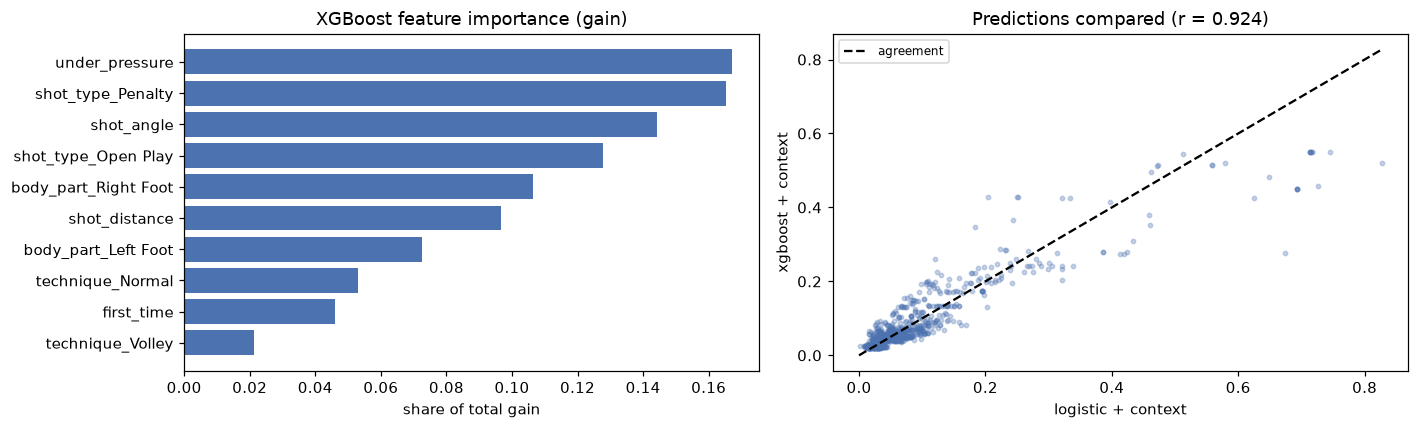

In [15]:
importance = xgbm.feature_importance(boosted.pipeline)
display(importance.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
top = importance.head(10).iloc[::-1]
axes[0].barh(top["feature"], top["share"], color="#4C72B0")
axes[0].set_xlabel("share of total gain")
axes[0].set_title("XGBoost feature importance (gain)")

axes[1].scatter(contextual_test, boosted_test, s=8, alpha=0.3, color="#4C72B0")
axes[1].plot(
    [0, max(contextual_test.max(), boosted_test.max())],
    [0, max(contextual_test.max(), boosted_test.max())],
    color="black",
    linestyle="--",
    label="agreement",
)
axes[1].set_xlabel("logistic + context")
axes[1].set_ylabel("xgboost + context")
axes[1].set_title(
    f"Predictions compared (r = {np.corrcoef(contextual_test, boosted_test)[0, 1]:.3f})"
)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

### 9a. Is the difference real, or is it this one split?

Section 7 warned that a single hold-out of 29 matches is one draw. Before drawing
any conclusion about which model is better, the same comparison is repeated across
eight different match-level splits. This is **not** hyperparameter tuning: the
models are unchanged, only the split varies.

In [16]:
rows = []
for seed in range(1, 9):
    repeat = val.group_train_test_split(shots, test_size=0.25, random_state=seed)
    truth = repeat.test["goal"].to_numpy()

    fitted_logistic = lg.fit(lg.build_contextual_model(random_state=SEED), repeat.train)
    fitted_boosted = xgbm.fit_with_early_stopping(
        xgbm.build_contextual_model(random_state=SEED), repeat.train, random_state=seed
    )
    logistic_metrics = mx.evaluate_probabilities(
        truth, lg.predict_probability(fitted_logistic, repeat.test)
    )
    boosted_metrics = mx.evaluate_probabilities(
        truth, lg.predict_probability(fitted_boosted.pipeline, repeat.test)
    )
    rows.append(
        {
            "seed": seed,
            "trees": fitted_boosted.n_trees,
            "logistic_auc": logistic_metrics.roc_auc,
            "xgboost_auc": boosted_metrics.roc_auc,
            "logistic_logloss": logistic_metrics.log_loss,
            "xgboost_logloss": boosted_metrics.log_loss,
        }
    )

repeats = pd.DataFrame(rows)
repeats["auc_difference"] = repeats["xgboost_auc"] - repeats["logistic_auc"]
display(repeats.round(4))

print(
    f"mean ROC-AUC   logistic {repeats['logistic_auc'].mean():.4f}   "
    f"xgboost {repeats['xgboost_auc'].mean():.4f}"
)
print(f"xgboost ahead on ROC-AUC in {(repeats['auc_difference'] > 0).sum()} of 8 splits")
print(
    f"xgboost ahead on log loss in "
    f"{(repeats['xgboost_logloss'] < repeats['logistic_logloss']).sum()} of 8 splits"
)
print(
    f"spread of logistic ROC-AUC across splits: "
    f"{repeats['logistic_auc'].min():.3f} to {repeats['logistic_auc'].max():.3f}"
)

,seed,trees,logistic_auc,xgboost_auc,logistic_logloss,xgboost_logloss,auc_difference
0,1,88,0.7322,0.7182,0.2876,0.2901,-0.0140
1,2,184,0.7910,0.7714,0.2643,0.2687,-0.0196
2,3,88,0.7375,0.7273,0.2998,0.2914,-0.0102
3,4,79,0.8057,0.7890,0.2586,0.2736,-0.0167
4,5,107,0.7252,0.7232,0.2985,0.2940,-0.0020
5,6,121,0.7661,0.7686,0.2461,0.2484,0.0025
6,7,72,0.7822,0.7618,0.2947,0.2974,-0.0204
7,8,177,0.8147,0.7777,0.2586,0.2710,-0.0370


mean ROC-AUC   logistic 0.7693   xgboost 0.7546
xgboost ahead on ROC-AUC in 1 of 8 splits
xgboost ahead on log loss in 2 of 8 splits
spread of logistic ROC-AUC across splits: 0.725 to 0.815


### What happened, and what to make of it

**Early stopping kept 89 of a possible 600 trees**, with the best validation loss
at iteration 48. The budget was never a binding constraint, which is the point of
setting it generously and letting the validation curve decide.

**On the headline split, boosting did not beat the logistic model.**

| model | ROC-AUC | PR-AUC | log loss | Brier skill |
| --- | ---: | ---: | ---: | ---: |
| base rate | 0.500 | 0.101 | 0.3263 | 0.000 |
| logistic distance + angle | 0.742 | 0.275 | 0.2903 | 0.084 |
| logistic + context | **0.757** | **0.300** | **0.2845** | **0.101** |
| xgboost + context | 0.734 | 0.268 | 0.2898 | 0.089 |
| StatsBomb xG (reference) | 0.784 | 0.400 | 0.2692 | 0.164 |

**And it is not an artefact of the split.** Across eight different match-level
splits, the logistic model has the better ROC-AUC in **seven of eight** and the
better log loss in six of eight, with mean ROC-AUC 0.769 against 0.755. Note also
that the spread *across splits* (0.725 to 0.815) is an order of magnitude larger
than the gap *between models* — which is the more important lesson about how much
a single number from one hold-out is worth.

**Why boosting has nothing to exploit here.** It buys the ability to represent
interactions and non-monotone responses. With 2,918 shots, 288 goals and a
relationship that really is close to monotone in distance and angle, there is
little of that to find, and the extra flexibility costs variance. This is the
expected outcome at this sample size, not a failure of the implementation — and it
is exactly why the project fits the interpretable baseline first.

**The cost side.** Boosting trains in 0.47 seconds against 0.013 for the logistic
model — roughly **35x** — while inference costs are essentially identical (4.8
against 4.6 microseconds per shot), since 89 shallow trees are cheap to evaluate.
So the real price is training time, and for a model that is not more accurate it is
a bad trade *here*. At ten or a hundred times the data the calculation would very
likely reverse.

**On feature importance, and how not to read it.** Gain says how much a feature was
*used*, not how it acts or in which direction. In this fit `under_pressure` and the
`shot_type` indicators score highly while `shot_distance` sits mid-table — which
does **not** mean distance matters less than pressure. The one-hot columns split
cleanly and cheaply, and the geometry information is spread across two correlated
continuous features that many shallow trees each use a little. Per-prediction
attribution needs SHAP, which comes later; the importance chart is a rough map of
where the model spent its splits, nothing more.

**What would change the conclusion.** More data (a full club season rather than two
tournaments), features with genuine interactions to find (freeze-frame defender
positions), or a calibration step. Any of those could make the flexible model the
better one. None of them is a reason to accept it *now*.

---

## 10. LightGBM, and a three-way comparison

Same algorithm family as XGBoost, with two engineering decisions that make it fast
and one that makes it dangerous on data this small.

### Histogram-based training

To split a node, a tree must find the best threshold on some feature. The direct
approach sorts the feature values and evaluates every candidate split: about
`O(rows x features)` per node, with the sorting work repeated at every level.

LightGBM **bins each feature once**, up front, into at most 255 buckets, then works
only with bin indices. Finding a split becomes a scan over histogram buckets rather
than over rows — `O(bins x features)`, **independent of the number of rows**.
Building a child's histogram is cheaper still: one child's histogram is the parent's
minus its sibling's, so only the smaller child is computed. Memory falls too, since
a bin index fits in a byte where a float needs eight.

The cost is precision: a threshold can only land on a bin edge. With 255 bins that
is rarely binding, and modern XGBoost uses a histogram method by default as well —
the gap between the libraries is narrower than its reputation suggests.

### Leaf-wise growth

XGBoost grows trees **level-wise**: every node at a given depth is split before
going deeper, so trees stay balanced and depth alone bounds complexity.

LightGBM grows **leaf-wise**: at each step it splits whichever leaf *anywhere* in
the tree promises the largest loss reduction. For the same number of leaves it
reaches a lower training loss, because the budget goes where it helps most.

### Why that overfits small datasets

Leaf-wise growth chases the largest available gain, and on a small dataset the
largest available gain is often noise. Nothing stops it driving a deep, narrow
branch down one path to isolate a handful of shots that happened to go in — a
memorised accident with the shape of a pattern. Level-wise growth cannot do this,
because it must spend its budget evenly.

Hence the configuration here: **`num_leaves = 8`, not the library default of 31**,
and `min_child_samples = 30`. With roughly 210 goals in the training data, the
defaults would let a single tree carve out individual shots. `max_depth = 3` is set
as a second, redundant bound so the two boosting models are constrained
comparably.

### Difference from XGBoost, at a high level

| | XGBoost | LightGBM |
| --- | --- | --- |
| Tree growth | level-wise (balanced) | leaf-wise (greedy) |
| Split search | histogram (also exact available) | histogram, with sibling subtraction |
| Complexity bounded mainly by | `max_depth` | `num_leaves` |
| Typical speed on small data | fast | faster |
| Risk on small data | overfits through too many trees | overfits through too-deep single branches |

Both optimise the same objective with the same shrinkage-and-subsampling defences.
The differences are about *how the tree is built*, not about what is being learned.

In [17]:
from football_intelligence.models import lightgbm as lgbm

start = time.perf_counter()
light = lgbm.fit_with_early_stopping(
    lgbm.build_contextual_model(random_state=SEED), split.train, random_state=SEED
)
light_train_seconds = time.perf_counter() - start
light_test = lg.predict_probability(light.pipeline, split.test)

print(light)
print()
print(f"  training time     {light_train_seconds:.3f}s")
print(f"  trees kept        {light.n_trees} of a budget of {lgbm.MAX_TREES}")
print(f"  leaf budget       {light.pipeline.named_steps['model'].num_leaves} leaves per tree")

  library           lightgbm
  early stopping    stopped at 50 trees
  best iteration    50
  validation loss   0.2943
  validation set    439 rows from 18 held-out training matches

  training time     0.032s
  trees kept        50 of a budget of 600
  leaf budget       8 leaves per tree


In [18]:
timings["lightgbm + context"] = light_train_seconds

start = time.perf_counter()
for _ in range(20):
    lg.predict_probability(light.pipeline, split.test)
inference["lightgbm + context"] = (time.perf_counter() - start) / 20

cost = pd.DataFrame(
    {
        "train_seconds": pd.Series(timings),
        "predict_seconds_per_746_shots": pd.Series(inference),
    }
)
cost["microseconds_per_shot"] = cost["predict_seconds_per_746_shots"] / len(split.test) * 1e6
cost["train_relative_to_logistic"] = (
    cost["train_seconds"] / cost.loc["logistic + context", "train_seconds"]
)
display(cost.round(4))

,train_seconds,predict_seconds_per_746_shots,microseconds_per_shot,train_relative_to_logistic
logistic distance + angle,0.0062,0.0015,2.0645,0.4307
logistic + context,0.0144,0.0036,4.8628,1.0000
xgboost + context,0.4882,0.0040,5.3027,33.8904
lightgbm + context,0.0321,0.0045,6.0529,2.2282


In [19]:
final = mx.compare_models(
    split.test["goal"],
    {
        "base rate": np.full(len(split.test), split.train["goal"].mean()),
        "logistic distance + angle": baseline_test,
        "logistic + context": contextual_test,
        "xgboost + context": boosted_test,
        "lightgbm + context": light_test,
        "StatsBomb xG (reference)": split.test["statsbomb_xg"].to_numpy(),
    },
)
display(
    final[
        [
            "roc_auc",
            "pr_auc",
            "log_loss",
            "log_loss_skill",
            "brier_score",
            "brier_skill",
            "mean_prediction",
        ]
    ].round(4)
)

,roc_auc,pr_auc,log_loss,log_loss_skill,brier_score,brier_skill,mean_prediction
base rate,0.5000,0.1005,0.3263,-0.0001,0.0904,-0.0001,0.0981
logistic distance + angle,0.7420,0.2753,0.2903,0.1102,0.0828,0.0841,0.0965
logistic + context,0.7568,0.2995,0.2845,0.1281,0.0813,0.1011,0.0980
xgboost + context,0.7344,0.2681,0.2898,0.1117,0.0824,0.0891,0.0959
lightgbm + context,0.7363,0.2676,0.2930,0.1020,0.0833,0.0791,0.0947
StatsBomb xG (reference),0.7840,0.4002,0.2692,0.1749,0.0756,0.1636,0.1042


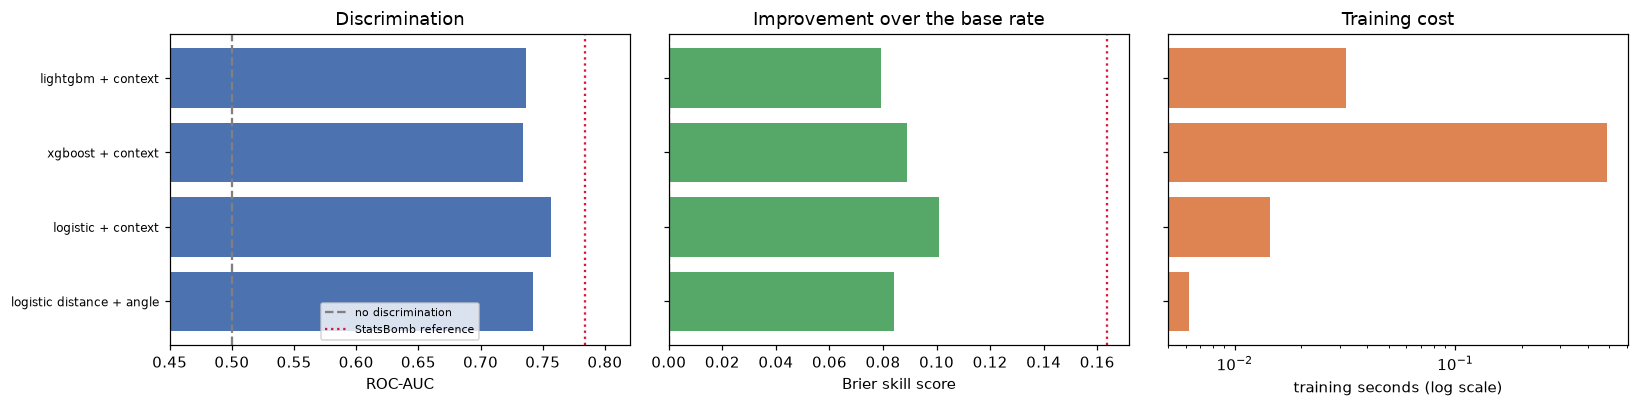

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

models = [
    "logistic distance + angle",
    "logistic + context",
    "xgboost + context",
    "lightgbm + context",
]
positions = np.arange(len(models))

axes[0].barh(positions, final.loc[models, "roc_auc"], color="#4C72B0")
axes[0].axvline(0.5, color="grey", linestyle="--", label="no discrimination")
axes[0].axvline(
    final.loc["StatsBomb xG (reference)", "roc_auc"],
    color="crimson",
    linestyle=":",
    label="StatsBomb reference",
)
axes[0].set_yticks(positions, models, fontsize=8)
axes[0].set_xlim(0.45, 0.82)
axes[0].set_xlabel("ROC-AUC")
axes[0].set_title("Discrimination")
axes[0].legend(fontsize=7)

axes[1].barh(positions, final.loc[models, "brier_skill"], color="#55A868")
axes[1].axvline(0, color="grey", linestyle="--")
axes[1].axvline(
    final.loc["StatsBomb xG (reference)", "brier_skill"], color="crimson", linestyle=":"
)
axes[1].set_yticks(positions, [""] * len(models))
axes[1].set_xlabel("Brier skill score")
axes[1].set_title("Improvement over the base rate")

axes[2].barh(positions, cost.loc[models, "train_seconds"], color="#DD8452")
axes[2].set_yticks(positions, [""] * len(models))
axes[2].set_xscale("log")
axes[2].set_xlabel("training seconds (log scale)")
axes[2].set_title("Training cost")
fig.tight_layout()
plt.show()

In [21]:
light_importance = lgbm.feature_importance(light.pipeline)
side_by_side = (
    importance.set_index("feature")[["share"]]
    .rename(columns={"share": "xgboost"})
    .join(light_importance.set_index("feature")[["share"]].rename(columns={"share": "lightgbm"}))
    .sort_values("lightgbm", ascending=False)
)
display(side_by_side.round(4))

,xgboost,lightgbm
feature,,
shot_angle,0.1444,0.4910
shot_distance,0.0966,0.2384
under_pressure,0.1671,0.0982
shot_type_Open Play,0.1279,0.0862
body_part_Right Foot,0.1064,0.0387
body_part_Left Foot,0.0724,0.0346
technique_Normal,0.0529,0.0099
technique_Volley,0.0213,0.0018
first_time,0.0459,0.0009


### Results

Early stopping kept **50 trees** for LightGBM against 89 for XGBoost, on the same
validation slice of 439 shots from 18 held-out training matches.

| model | ROC-AUC | PR-AUC | log loss | Brier score | Brier skill |
| --- | ---: | ---: | ---: | ---: | ---: |
| base rate | 0.500 | 0.101 | 0.3263 | 0.0904 | 0.000 |
| logistic distance + angle | 0.742 | 0.275 | 0.2903 | 0.0828 | 0.084 |
| **logistic + context** | **0.757** | **0.300** | **0.2845** | **0.0813** | **0.101** |
| xgboost + context | 0.734 | 0.268 | 0.2898 | 0.0824 | 0.089 |
| lightgbm + context | 0.736 | 0.268 | 0.2930 | 0.0833 | 0.079 |
| StatsBomb xG (reference) | 0.784 | 0.400 | 0.2692 | 0.0756 | 0.164 |

**The two boosting libraries agree with each other and both trail the logistic
model.** ROC-AUC 0.734 and 0.736 against 0.757; log loss 0.290 and 0.293 against
0.285. That two independent implementations, with different tree-growth strategies,
land within 0.002 of each other is itself informative: the ceiling here is the
data, not the library. Section 9a already showed the XGBoost gap holds across eight
splits, and **no alternative split was tried to improve on this one**.

**Speed is where LightGBM wins decisively.** It trains roughly an order of
magnitude faster than XGBoost while producing an equivalent model. On 2,172 rows
that is roughly 0.03 seconds against 0.5, a 15-20x gap of no practical consequence here — but it is the same ratio that makes LightGBM the default
choice at a hundred times the scale. Inference costs are close for all four models;
89 or 50 shallow trees are cheap to evaluate.

**Feature importance disagrees sharply between the two libraries**, and that is the
lesson rather than a problem. LightGBM attributes about half its total gain to
`shot_angle` and a quarter to `shot_distance`; XGBoost spreads gain much more
evenly and puts `under_pressure` and the `shot_type` indicators at the top. Same
data, same features, same target — different tree shapes, therefore different
bookkeeping. Built-in importances are **not comparable across libraries** and should
not be quoted as if they measured a property of the football. A model-agnostic
attribution method is needed for that, and comes later.

---

## 11. CatBoost, and the categorical target-leakage problem

The third boosting library, and the only one here that treats categorical
variables as first-class rather than something to encode away. Two ideas do the
work, and both exist to solve the same problem.

### The target-leakage problem in categorical encoding

The obvious way to hand a tree a categorical feature is **target encoding**:
replace each level with the mean of the target for that level. `Head` becomes
0.111, because 11.1% of headers were goals.

Computed naively this **leaks**. The mean for `Head` includes *this shot's own
outcome*, so a header that scored is handed a slightly inflated number and one
that missed a slightly deflated one. The feature carries a trace of the answer.
Training loss collapses, the model leans on the encoding, and the advantage
evaporates on new data. The effect is worst exactly where the encoding is most
tempting: a level appearing once is encoded as its own outcome, 0 or 1.

This is not an exotic failure. It is the single most common way a tabular model
with categorical features is quietly ruined.

### Ordered target statistics

CatBoost imposes an artificial "time". It draws a random permutation of the
training rows and, for each row, computes its categorical statistic using **only
the rows that precede it**, smoothed toward a prior:

```
encoding = (targets of earlier rows in this category + a * prior) / (count + a)
```

No row can see its own outcome, so the encoding is honest. Rows early in the
permutation get noisy estimates dominated by the prior, which is why several
permutations are maintained and averaged.

### Ordered boosting

The same leak appears in boosting itself. Standard gradient boosting computes the
residual for a row from a model that was trained *on that row*, so residuals are
optimistically small and the ensemble drifts — the "prediction shift" that makes
boosted models overfit small data. Ordered boosting applies the same permutation
trick to the gradients: each row's residual comes from a model trained only on
rows preceding it. It costs compute and buys an unbiased gradient estimate, which
matters most when data is scarce — as it is here.

### Why this suits categorical tabular data

- High-cardinality categoricals cost **one column, not one per level**.
- The encoding carries the category's *relationship to the target*, rather than
  mere membership that a tree must rediscover through many splits.
- Combinations of categoricals are constructed automatically, so interactions
  between body part and shot type need no hand engineering.

### When XGBoost or LightGBM is still preferable

- **Mostly numeric problems** — ordered target statistics solve a problem you do
  not have, and you pay for them in training time.
- **Low-cardinality categoricals** — with four body parts and three shot types,
  one-hot costs almost nothing and is easier to reason about. That is exactly
  this dataset, so CatBoost's headline advantage has little room here.
- **Large data or tight training budgets** — ordered boosting maintains several
  permutations and is markedly slower per iteration than LightGBM's histograms.
- **Ecosystem weight** — wider tooling, deployment and explainability support.

### On `player_id` and `team_id`

These are precisely the high-cardinality categoricals CatBoost is famous for, and
they are deliberately **not used**. The model layer refuses them without an
explicit opt-in, for reasons that are about this dataset rather than about
CatBoost:

- **`player_id`** has 651 levels with a **median of 3 shots each**. A per-player
  target statistic estimated from three observations is mostly noise.
- Worse, **the evaluation split is by match, not by player**, so the same players
  appear on both sides. The model would be rewarded for remembering individuals,
  and the score would not transfer to a player it has never seen. The statistics
  notebook already showed that player clustering, not match clustering, is where
  the dependence in this data lives.
- **xG is meant to describe the quality of a chance, not who took it.** A
  player-conditioned model answers a different question — a legitimate one, but it
  needs a player-grouped split and a different name.

In [22]:
from football_intelligence.models import catboost as cb

print("Identifier columns the model layer refuses, and why:")
print()
for name, reason in cb.IDENTIFIER_FEATURES.items():
    print(f"  {name}")
    print(f"      {reason}")
    print()

try:
    cb.build_catboost_model(("shot_distance",), ("player_id",), ())
except cb.ModelError as error:
    print(f"refused -> {str(error)[:110]}...")

Identifier columns the model layer refuses, and why:

  player_id
      651 players with a median of 3 shots each: a per-player target statistic is estimated from three observations and is mostly noise. Worse, the evaluation split is by match, so the same players appear in train and test -- the model would be rewarded for remembering individuals rather than for modelling chances, and the score would not transfer to a player it has not seen

  team_id
      44 teams sharing the same match-level split, so team identity crosses the train/test boundary in the same way; and xG is meant to describe the quality of a chance, not who took it

  match_id
      the grouping variable of the evaluation split, not a property of the shot

refused -> 'player_id' is an identifier, not a shot property: 651 players with a median of 3 shots each: a per-player tar...


In [23]:
start = time.perf_counter()
cat = cb.fit_with_early_stopping(
    cb.build_contextual_model(random_state=SEED), split.train, random_state=SEED
)
cat_train_seconds = time.perf_counter() - start
cat_test = lg.predict_probability(cat.pipeline, split.test)

print(cat)
print()
print(f"  training time     {cat_train_seconds:.3f}s")
print(f"  categoricals      {cb.categorical_feature_names(cat.pipeline)} (handled natively)")

  library           catboost
  early stopping    stopped at 86 trees
  best iteration    85
  validation loss   0.2916
  validation set    439 rows from 18 held-out training matches

  training time     0.413s
  categoricals      ['body_part', 'shot_type', 'technique'] (handled natively)


In [24]:
timings["catboost + context"] = cat_train_seconds

start = time.perf_counter()
for _ in range(20):
    lg.predict_probability(cat.pipeline, split.test)
inference["catboost + context"] = (time.perf_counter() - start) / 20

everything = mx.compare_models(
    split.test["goal"],
    {
        "base rate": np.full(len(split.test), split.train["goal"].mean()),
        "logistic distance + angle": baseline_test,
        "logistic + context": contextual_test,
        "xgboost + context": boosted_test,
        "lightgbm + context": light_test,
        "catboost + context": cat_test,
        "StatsBomb xG (reference)": split.test["statsbomb_xg"].to_numpy(),
    },
)
cost = pd.DataFrame(
    {
        "train_seconds": pd.Series(timings),
        "predict_seconds": pd.Series(inference),
    }
)
cost["microseconds_per_shot"] = cost["predict_seconds"] / len(split.test) * 1e6

final_table = everything[["roc_auc", "pr_auc", "log_loss", "brier_score", "brier_skill"]].join(
    cost[["train_seconds", "microseconds_per_shot"]]
)
display(final_table.round(4))

,roc_auc,pr_auc,log_loss,brier_score,brier_skill,train_seconds,microseconds_per_shot
base rate,0.5000,0.1005,0.3263,0.0904,-0.0001,NaN,NaN
logistic distance + angle,0.7420,0.2753,0.2903,0.0828,0.0841,0.0062,2.0645
logistic + context,0.7568,0.2995,0.2845,0.0813,0.1011,0.0144,4.8628
xgboost + context,0.7344,0.2681,0.2898,0.0824,0.0891,0.4882,5.3027
lightgbm + context,0.7363,0.2676,0.2930,0.0833,0.0791,0.0321,6.0529
catboost + context,0.7550,0.2957,0.2933,0.0843,0.0677,0.4135,4.6919
StatsBomb xG (reference),0.7840,0.4002,0.2692,0.0756,0.1636,NaN,NaN


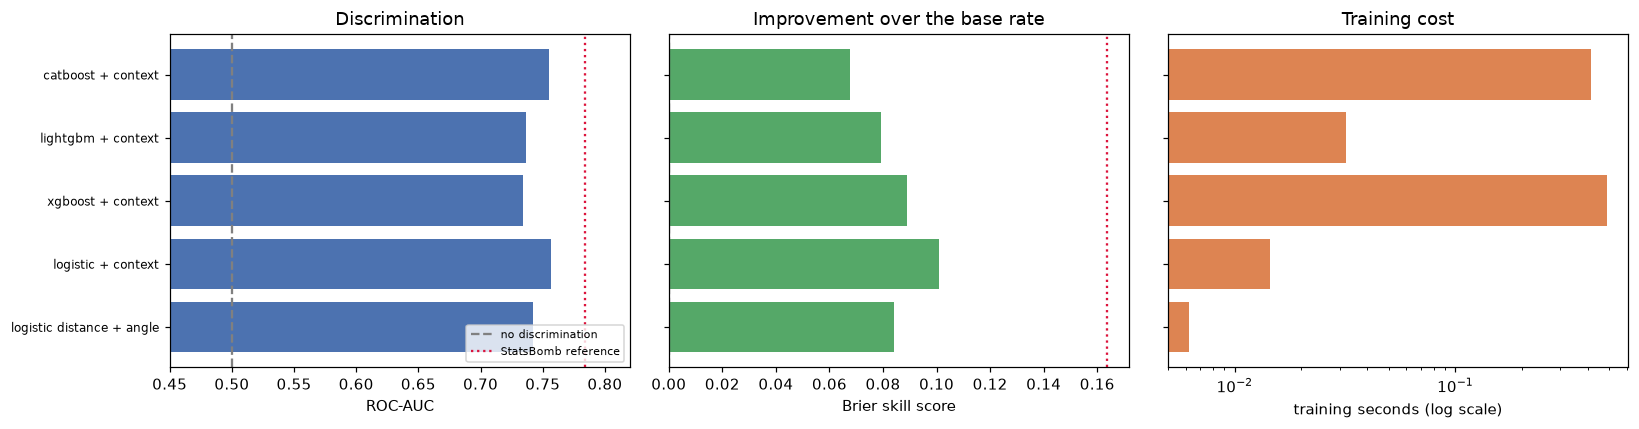

In [25]:
models = [
    "logistic distance + angle",
    "logistic + context",
    "xgboost + context",
    "lightgbm + context",
    "catboost + context",
]
positions = np.arange(len(models))
reference_auc = everything.loc["StatsBomb xG (reference)", "roc_auc"]
reference_skill = everything.loc["StatsBomb xG (reference)", "brier_skill"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))

axes[0].barh(positions, everything.loc[models, "roc_auc"], color="#4C72B0")
axes[0].axvline(0.5, color="grey", linestyle="--", label="no discrimination")
axes[0].axvline(reference_auc, color="crimson", linestyle=":", label="StatsBomb reference")
axes[0].set_yticks(positions, models, fontsize=8)
axes[0].set_xlim(0.45, 0.82)
axes[0].set_xlabel("ROC-AUC")
axes[0].set_title("Discrimination")
axes[0].legend(fontsize=7, loc="lower right")

axes[1].barh(positions, everything.loc[models, "brier_skill"], color="#55A868")
axes[1].axvline(0, color="grey", linestyle="--")
axes[1].axvline(reference_skill, color="crimson", linestyle=":")
axes[1].set_yticks(positions, [""] * len(models))
axes[1].set_xlabel("Brier skill score")
axes[1].set_title("Improvement over the base rate")

axes[2].barh(positions, cost.loc[models, "train_seconds"], color="#DD8452")
axes[2].set_yticks(positions, [""] * len(models))
axes[2].set_xscale("log")
axes[2].set_xlabel("training seconds (log scale)")
axes[2].set_title("Training cost")
fig.tight_layout()
plt.show()

In [26]:
print("CatBoost importance is per original feature, not per one-hot column:")
display(cb.feature_importance(cat.pipeline).round(4))

CatBoost importance is per original feature, not per one-hot column:


,feature,importance,share
0,shot_angle,39.8883,0.3989
1,shot_distance,30.9232,0.3092
2,shot_type,10.7880,0.1079
3,under_pressure,8.2599,0.0826
4,body_part,7.1239,0.0712
5,first_time,1.8811,0.0188
6,technique,1.1358,0.0114


### The final comparison

| model | ROC-AUC | PR-AUC | log loss | Brier | Brier skill | train (s) |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| base rate | 0.500 | 0.101 | 0.3263 | 0.0904 | 0.000 | — |
| logistic distance + angle | 0.742 | 0.275 | 0.2903 | 0.0828 | 0.084 | ~0.006 |
| **logistic + context** | **0.757** | **0.300** | **0.2845** | **0.0813** | **0.101** | ~0.014 |
| xgboost + context | 0.734 | 0.268 | 0.2898 | 0.0824 | 0.089 | ~0.5 |
| lightgbm + context | 0.736 | 0.268 | 0.2930 | 0.0833 | 0.079 | ~0.03 |
| catboost + context | 0.755 | 0.296 | 0.2933 | 0.0843 | 0.068 | ~0.4 |
| StatsBomb xG (reference) | 0.784 | 0.400 | 0.2692 | 0.0756 | 0.164 | — |

The metrics are deterministic given the seed; the timings are not, and vary by tens
of percent between runs on a shared machine, so they are quoted to one significant
figure and only the order of magnitude should be read. Inference is not a
distinguishing factor at all: every model scores the 746 test shots in a few
milliseconds, 2-6 microseconds per shot, and the exact cell output above carries the
precise figures for this run.

**CatBoost is the best of the three boosting libraries on ranking**, essentially
matching the logistic model on ROC-AUC (0.755 against 0.757) and PR-AUC (0.296
against 0.300), where XGBoost and LightGBM sat around 0.735 and 0.268. Ordered
boosting is the plausible reason: an unbiased gradient estimate is worth most
exactly when there are only ~210 goals to learn from.

**But it is, narrowly, the worst of the four on the probability metrics** — log
loss 0.2933 against LightGBM's 0.2930 and the logistic model's 0.2845, and a Brier
score of 0.0843 that is the highest of any fitted model here. That
combination, *better ordering with worse-scored probabilities*, is precisely why
this project reports both families of metric. A model that ranks chances well but
whose numbers are not trustworthy as probabilities is the wrong tool for xG, where
the number itself is the product. Calibration is the next task, and CatBoost is
the model most likely to be changed by it.

**The logistic baseline still wins overall**, on the metrics that matter most for a
probability model, at roughly a thirtieth of the training cost of either CatBoost
or XGBoost. Four models, three of them far more flexible, and none beat the
interpretable one on this dataset — which is a result about the data, not about
the libraries: 2,918 shots and 288 goals do not contain enough structure for
flexibility to pay for itself.

**Importance is finally readable.** CatBoost reports one number per *original*
feature, so `shot_angle` (0.40) and `shot_distance` (0.31) top the table with
`shot_type` (0.11), `under_pressure` (0.08) and `body_part` (0.07) behind. That
ordering matches football intuition and the exploratory analysis, and it is far
easier to read than the one-hot importances of the other two libraries — though it
remains a statement about where this model spent its splits, and is still not
comparable across libraries.

**Cost.** CatBoost trains in about 0.4 seconds, comparable to XGBoost and an order
of magnitude slower than LightGBM, which is the expected price of maintaining
several permutations for ordered boosting. Early stopping kept 86 trees, against 89
for XGBoost and 50 for LightGBM, on the same validation slice of 439 shots from 18
held-out training matches.

---

## 12. Limitations

**Of the evaluation**

1. **One split of 29 matches.** Every number here is a single draw. Grouped
   cross-validation is needed before any of these differences can be called real,
   and the difference between 0.742 and 0.757 is well within what a different seed
   would produce.
2. **Discrimination is reported, calibration barely.** Mean prediction matches
   observed prevalence, but that is calibration *in the large* only. Whether shots
   predicted at 0.3 actually score 30% of the time is unexamined here.
3. **Matches, not players.** Grouping by match removes the most obvious leakage.
   Shots are also clustered within players, and the statistics notebook showed that
   player clustering matters more than match clustering for shot geometry. A model
   evaluated on unseen matches may still be evaluated on very familiar players.

**Of the models**

4. **The logistic model is additive and monotone by construction.** It cannot
   represent an interaction or a non-monotone response. Both certainly exist — but
   §9 showed that the boosted model, which *can* represent them, does not find
   enough of them to be worth its variance at this sample size.
5. **No spatial context.** The single largest gap to the reference model is that we
   do not know where the goalkeeper and defenders were. The freeze frame is in the
   raw data for open-play shots and is the obvious next feature source.
6. **Penalties are modelled alongside open play.** 46 penalties with a near-constant
   location and a 67% conversion rate are being fitted by the same predictor as
   open-play shots. A flag lets the model shift the intercept, but a separate
   treatment would be more honest.
7. **The boosting hyperparameters were set, not tuned.** They are defensible
   defaults for both libraries; a grouped cross-validated search might close the
   gap, and might not. What would be indefensible is tuning them against the test
   set, or trying splits until a favoured model wins.
8. **Built-in feature importances are not comparable across libraries**, as §10
   and §11 show concretely. They describe where each model spent its splits, not
   how much any feature matters to scoring a goal.
9. **Identifier features are excluded by design.** `player_id` and `team_id` would
   let a model remember individuals across a split that does not separate them.
   Answering "does this player finish well?" needs a player-grouped split and a
   different framing, not a bigger feature list.

**Of the data**

7. **2,918 shots and 288 goals.** The positive class is what limits everything: a
   model with a dozen parameters is being fitted to fewer than 300 events.
8. **Coordinate precision differs by competition** — World Cup coordinates are
   whole yards, Euro coordinates are not — so `shot_distance` carries measurement
   error that is confounded with competition.
9. **Two men's international tournaments.** Nothing here should be assumed to
   transfer to club football without re-fitting.

**What comes next**: calibration analysis — the gap between CatBoost's ranking and
its probability scores is the clearest signal that it is needed — and grouped
cross-validation to replace the single hold-out, so the differences in the table
above can be given intervals rather than read as facts.